In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/hafsaferdousi5/stacking-ensemble/stacking_ensemble_classification_report.csv
/kaggle/input/datasets/hafsaferdousi5/stacking-ensemble/stacking_ensemble.csv
/kaggle/input/notebooks/hafsaferdousi5/ensemble/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/ensemble/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/ensemble/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/ensemble/custom.css
/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/custom.css
/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/outputs/results/lightgbm_leaves31_metrics.csv
/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/outputs/results/lightgbm_leaves31_classification_report.csv
/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm

In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

plt.style.use("ggplot")
sns.set(font_scale=1.1)


os.makedirs("comparison_results", exist_ok=True)
os.makedirs("comparison_figures", exist_ok=True)

In [3]:
rf = pd.read_csv("/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/outputs/results/rf_metrics.csv")
xgb = pd.read_csv("/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/outputs/results/Xgboost_metrics.csv")
lgb = pd.read_csv("/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/outputs/results/lightgbm_leaves31_metrics.csv")
cat = pd.read_csv("/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/outputs/results/catb_metrics.csv")
stacking = pd.read_csv("/kaggle/input/datasets/hafsaferdousi5/stacking-ensemble/stacking_ensemble.csv")


In [4]:
rf["Model"] = "Random Forest"
xgb["Model"] = "XGBoost"
lgb["Model"] = "LightGBM"
cat["Model"] = "CatBoost"
stacking["Model"] = "Stacking"

results = pd.concat(
    [rf, xgb, lgb, cat,stacking],
    ignore_index=True
)

cols = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC",
    "MCC"
]

results = results[cols]

results

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
0,Random Forest,0.974647,0.967166,0.974647,0.970695,0.981203,0.929508
1,XGBoost,0.981959,0.975358,0.981959,0.974499,0.992736,0.950122
2,LightGBM,0.813626,0.822829,0.813626,0.796905,0.701754,0.430746
3,CatBoost,0.981601,0.975901,0.981601,0.973464,0.990054,0.949153
4,Stacking,0.971724,0.967380,0.971724,0.969494,0.987810,0.921724


In [5]:
ranking = results.sort_values(
    by=["F1","Accuracy","AUC"],
    ascending=False
).reset_index(drop=True)

ranking.index = ranking.index + 1

ranking

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
1,XGBoost,0.981959,0.975358,0.981959,0.974499,0.992736,0.950122
2,CatBoost,0.981601,0.975901,0.981601,0.973464,0.990054,0.949153
3,Random Forest,0.974647,0.967166,0.974647,0.970695,0.981203,0.929508
4,Stacking,0.971724,0.967380,0.971724,0.969494,0.987810,0.921724
5,LightGBM,0.813626,0.822829,0.813626,0.796905,0.701754,0.430746


In [6]:
results.dtypes

Model         object
Accuracy     float64
Precision    float64
Recall       float64
F1           float64
AUC          float64
MCC          float64
dtype: object

In [7]:
print(results.columns.tolist())

['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'MCC']


In [8]:

results.style \
    .highlight_max(
        subset=["Accuracy", "Precision", "Recall", "F1", "AUC","MCC"],
        color="lightgreen"
    ) \
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}",
        "MCC": "{:.4f}"
    })

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
0,Random Forest,0.9746,0.9672,0.9746,0.9707,0.9812,0.9295
1,XGBoost,0.9820,0.9754,0.9820,0.9745,0.9927,0.9501
2,LightGBM,0.8136,0.8228,0.8136,0.7969,0.7018,0.4307
3,CatBoost,0.9816,0.9759,0.9816,0.9735,0.9901,0.9492
4,Stacking,0.9717,0.9674,0.9717,0.9695,0.9878,0.9217


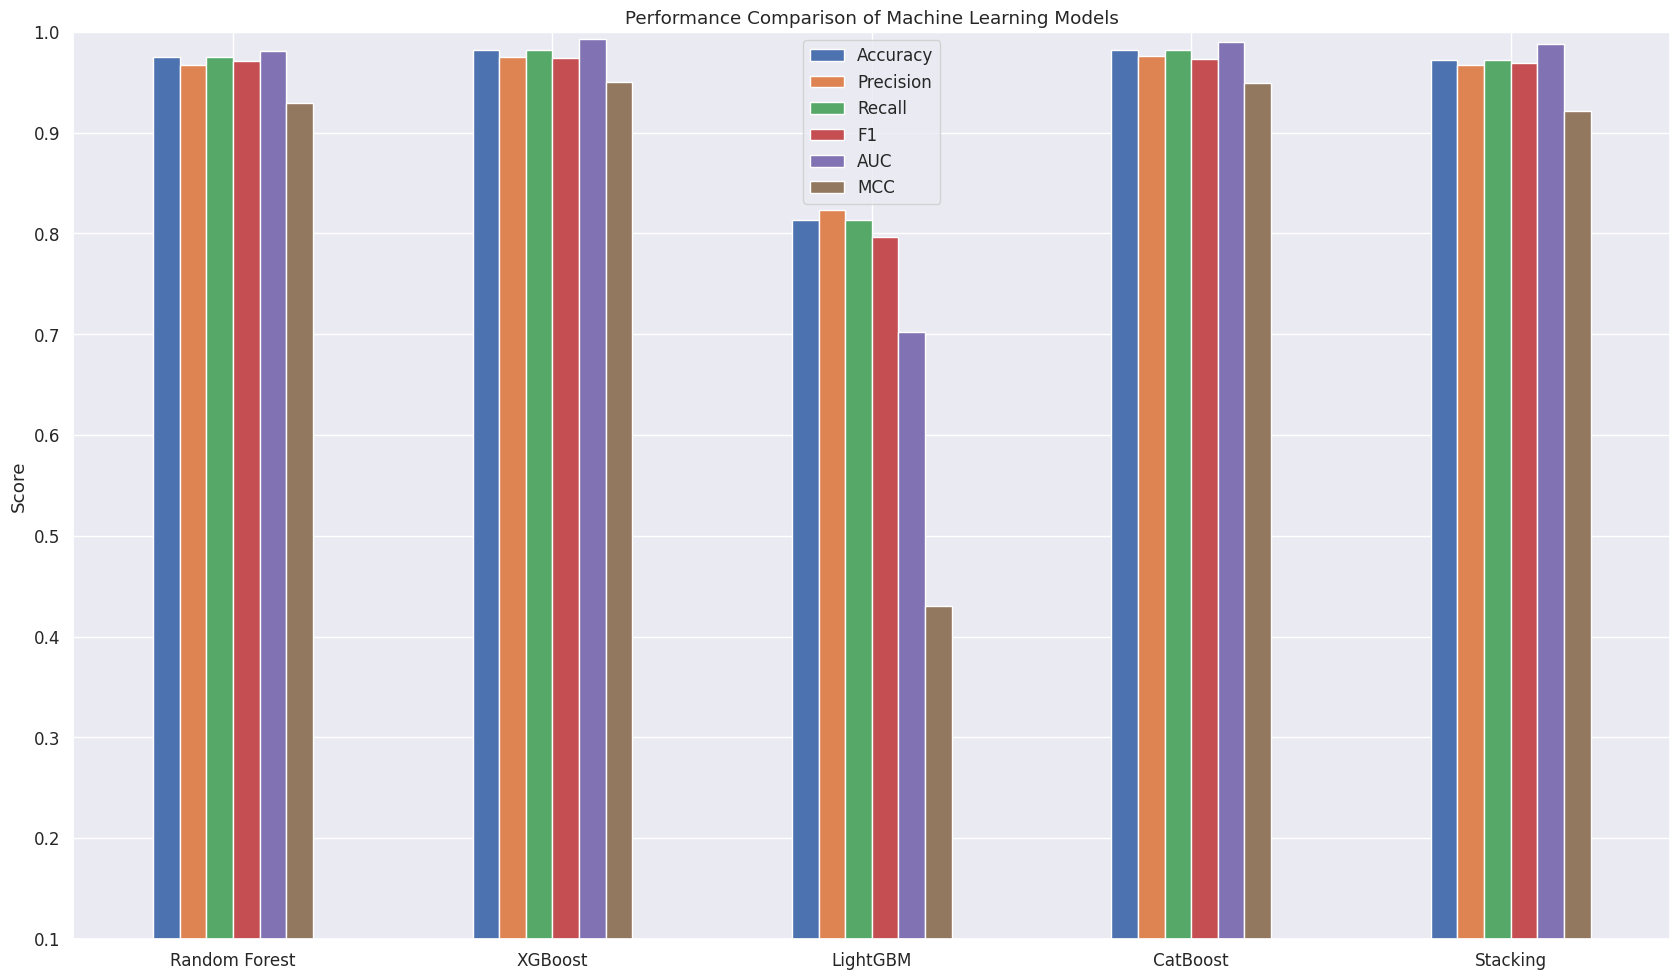

In [9]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC",
    "MCC"
]

ax = results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(17,10),
    rot=0
)

plt.ylabel("Score")
plt.xlabel("")
plt.title("Performance Comparison of Machine Learning Models")
plt.ylim(0.1,1)
plt.grid(True)

plt.tight_layout()



plt.show()

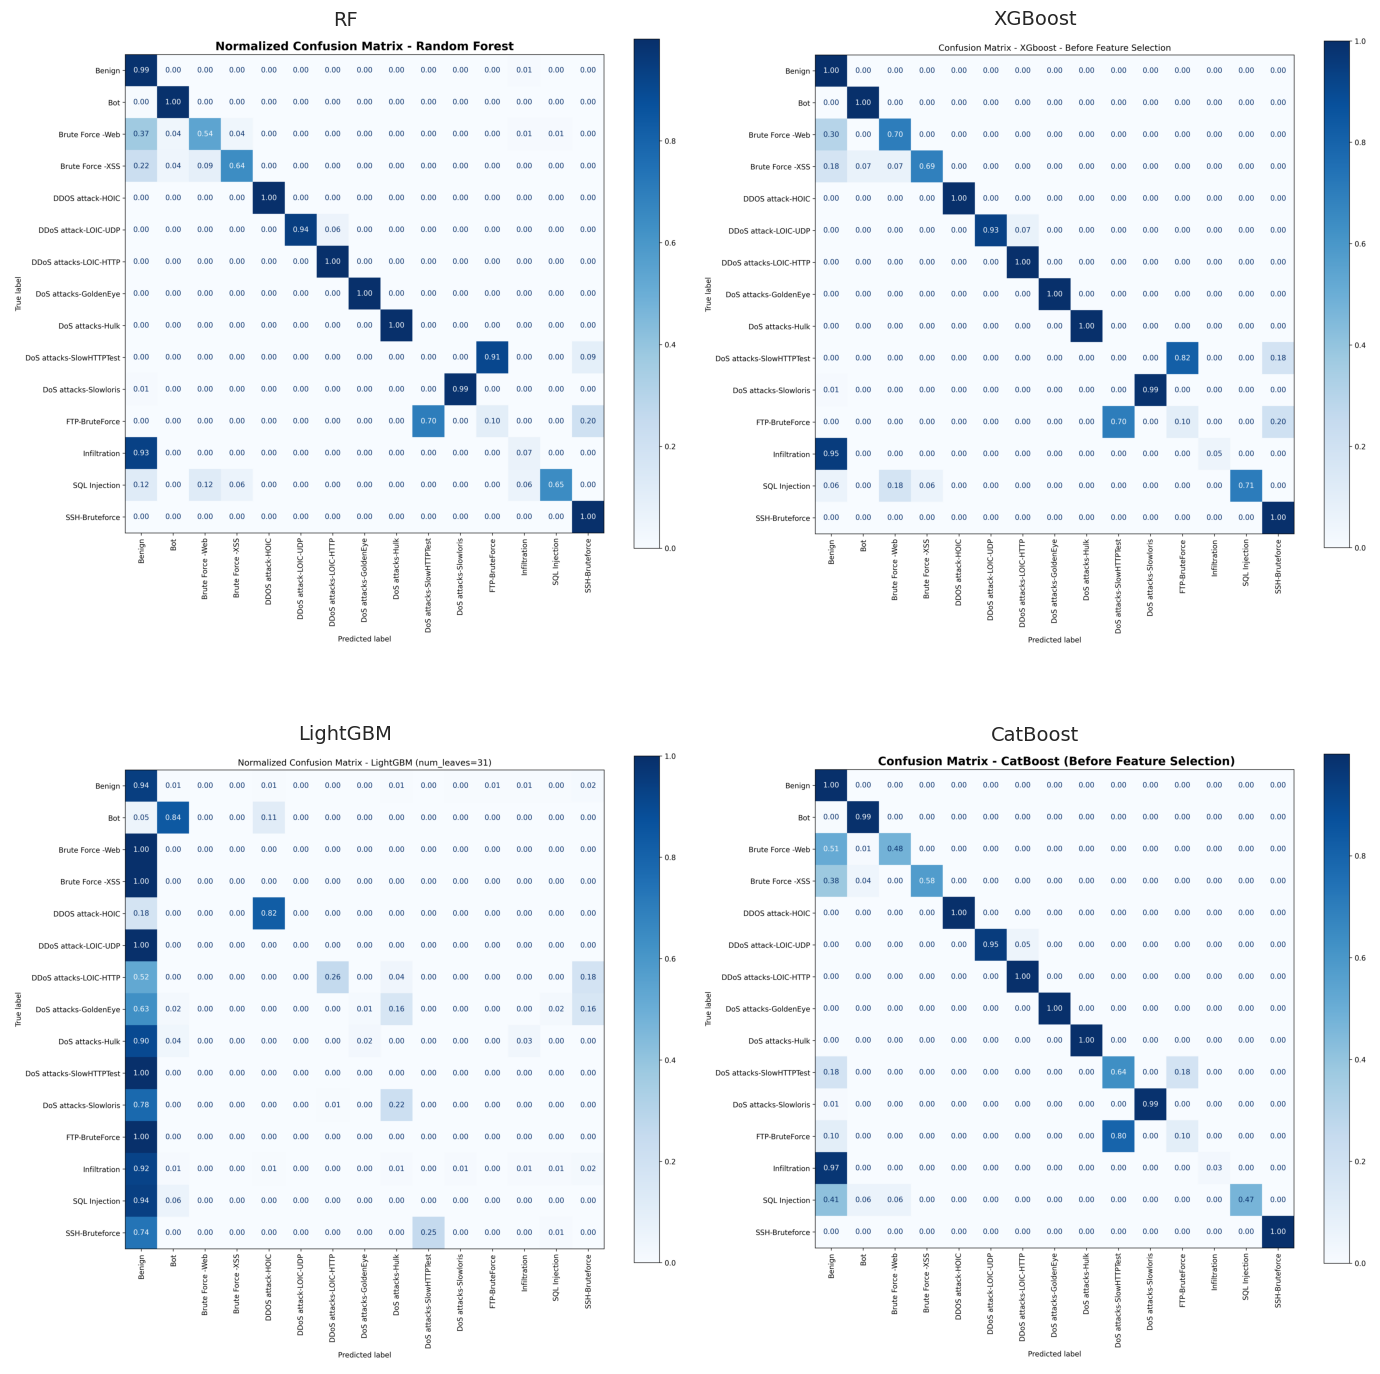

In [10]:
fig, axes = plt.subplots(2,2,figsize=(14,15))

images = [
    ("RF","/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/outputs/results/rf_confusion_matrix.png"),
    ("XGBoost","/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/outputs/results/xgb_confusion_matrix.png"),
    ("LightGBM","/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/outputs/results/lightgbm_leaves31_confusion_matrix.png"),
    ("CatBoost","/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/outputs/results/catb_confusion_matrix.png")
]

for ax,(title,path) in zip(axes.flatten(),images):

    img = Image.open(path)

    ax.imshow(img)

    ax.set_title(title,fontsize=14)

    ax.axis("off")

plt.tight_layout()



plt.show()

In [11]:
plt.savefig(
    "comparison_figures/confusion_matrix_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [12]:
results.to_csv(
    "comparison_results/model_comparison.csv",
    index=False
)

results

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
0,Random Forest,0.974647,0.967166,0.974647,0.970695,0.981203,0.929508
1,XGBoost,0.981959,0.975358,0.981959,0.974499,0.992736,0.950122
2,LightGBM,0.813626,0.822829,0.813626,0.796905,0.701754,0.430746
3,CatBoost,0.981601,0.975901,0.981601,0.973464,0.990054,0.949153
4,Stacking,0.971724,0.967380,0.971724,0.969494,0.987810,0.921724


In [13]:
ranking.to_csv(
    "comparison_results/model_ranking.csv",
    index=True
)

In [14]:

plt.savefig(
    "comparison_figures/model_comparison_bar.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>